# 01 — LGBM v1: Joint MODEL_GRID + Feature-Selection Search · M2Y WFO · Long+Short (with fees)

**What this notebook does**
- Walk-forward (sliding 2-year, monthly step) LightGBM probability model, identical fee model to v12.
- **Joint search** over a *model* grid (`num_leaves`, `min_child_samples`, `learning_rate`) → 8 configs;
  feature-selection grid is fixed (`top_n_features=50`, `corr_threshold=0.85`) — Boruta prunes downstream.
- Feature selection = relevance–redundancy filter (univariate AUC → Spearman redundancy prune → top-N).
- For each config: WFO → validation probs → exhaustive trading grid (v12 grid). Best config chosen by
  **validation Sharpe** subject to a **≥120-trade floor** (prevents the near-dormant high-threshold configs
  that left earlier versions flat for months). OOS is held out for final reporting only.
- Overwrites `artifacts/notebooks_v2/01_lgbm/` consumed by `04_meta_learning_v1`.

In [1]:
import calendar, itertools, json, time, warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
mpl.rcParams.update({
    'font.family':'serif','font.serif':['DejaVu Serif'],
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':10,'axes.titlesize':11,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':120,'savefig.dpi':200,'savefig.bbox':'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

def _repo_root():
    p = Path.cwd()
    while p != p.parent:
        if (p/'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO     = _repo_root()
ARTS_DIR = REPO/'artifacts'/'notebooks_v2'/'01_lgbm'
ARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── WFO / OOS (unified across notebooks_v2) ──────────────────────────
OOS_START      = pd.Timestamp('2024-06-01')
GRID_VAL_START = pd.Timestamp('2022-01-01')
GRID_VAL_END   = pd.Timestamp('2024-05-30')
TRAIN_WINDOW_H = 17520     # sliding 2-year window (M2Y) — spans a full bull→bear regime flip
STEP_SIZE      = 720       # monthly step
EMBARGO        = 12
VAL_FRAC       = 0.20
LABEL_COL      = 'label'

# ── Fee model (spot longs + futures shorts), identical to v12 ────────
MAKER_FEE=0.0000; SPOT_TAKER_FEE=0.0005; FUTURES_TAKER_FEE=0.0005
BUFFER=0.0005; SHORT_FUNDING_H=0.0000077

# ── Joint search grids ───────────────────────────────────────────────
MODEL_GRID = {
    'top_n_features':    [50],          # fixed; Boruta prunes downstream
    'corr_threshold':    [0.85],         # fixed; Boruta prunes downstream
    'num_leaves':        [31, 63],
    'min_child_samples': [30, 50],
    'learning_rate':     [0.01, 0.02],
}
TRADING_GRID = {                      # identical to v12
    'long_threshold':  [0.55, 0.58, 0.60, 0.63],
    'short_threshold': [0.30, 0.35, 0.40],
    'entry_atr_mult':  [0.3, 0.6, 1.0],
    'sl_atr_mult':     [1.5, 2.0, 2.5],
    'tp_atr_mult':     [2.0, 2.5, 3.0],
    'min_sl':          [0.010, 0.015],
    'min_hold':        [4, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}
LGBM_BASE = dict(max_depth=6, colsample_bytree=0.5, subsample=0.7,
                 reg_alpha=0.1, reg_lambda=1.0, n_estimators=500,
                 objective='binary', metric='auc', verbose=-1, random_state=42, n_jobs=-1)
MIN_TRADES_VAL = 120                  # validation selection floor -> guarantees regular trading
MIN_TRADES_OOS = 120                  # reporting floor retained for comparability
EXCLUDE = {'open','high','low','close','volume', LABEL_COL,
           'sma_200','mkt_stablecoin_pct','mkt_total_mcap_chg_24h'}
_tkeys   = list(TRADING_GRID); _tcombos = list(itertools.product(*TRADING_GRID.values()))
_mkeys   = list(MODEL_GRID);   _mcombos = list(itertools.product(*MODEL_GRID.values()))
print(f'Model grid: {len(_mcombos)} configs  |  Trading grid: {len(_tcombos)} combos')
print(f'Selection: validation Sharpe, OOS held out  |  OOS {OOS_START.date()} → 2-yr')

Model grid: 8 configs  |  Trading grid: 5184 combos
Selection: validation Sharpe, OOS held out  |  OOS 2024-06-01 → 2-yr


In [2]:
UNIFIED = REPO / 'data' / 'features' / 'BTCUSDT_1h_unified.parquet'
if not UNIFIED.exists():
    raise FileNotFoundError(f'{UNIFIED} not found — run 00_data_ingestion_v1.ipynb first.')
df = pd.read_parquet(UNIFIED)
df.index = df.index.tz_localize(None) if df.index.tz else df.index
val_mask = (df.index >= GRID_VAL_START) & (df.index < OOS_START)
val_df   = df[val_mask].copy()
oos_mask = df.index >= OOS_START
oos_df   = df[oos_mask].copy()

def build_candidate_pool(df):
    num = df.select_dtypes(include=[np.number]).columns
    pre = df[df.index < OOS_START]
    keep = []
    for c in num:
        if c in EXCLUDE: continue
        s = pre[c]
        if s.notna().sum() < 1000 or s.std(skipna=True) < 1e-9: continue
        keep.append(c)
    return keep

POOL = build_candidate_pool(df)
print(f'Unified parquet : {df.shape}  ({df.index.min().date()} → {df.index.max().date()})')
print(f'OOS bars        : {oos_mask.sum():,}  ({OOS_START.date()} → {df.index[-1].date()})')
print(f'Candidate pool  : {len(POOL)} features  |  Label dist {df[LABEL_COL].value_counts().to_dict()}')

Unified parquet : (77036, 291)  (2017-08-17 → 2026-05-31)
OOS bars        : 17,520  (2024-06-01 → 2026-05-31)
Candidate pool  : 279 features  |  Label dist {1: 39136, 0: 37900}


In [3]:
# ── Relevance–redundancy feature selection (filter family) ───────────────────
def rank_features(df, pool):
    pre = df[df.index < OOS_START]; y = pre[LABEL_COL].values
    auc = {}
    for c in pool:
        try: a = roc_auc_score(y, pre[c].fillna(0.0).values)
        except Exception: continue
        auc[c] = max(a, 1 - a)                       # direction-agnostic relevance
    survivors = sorted([c for c in pool if auc.get(c,0) > 0.502], key=lambda c: auc[c], reverse=True)
    X = pre[survivors].fillna(0.0).values
    rho = np.abs(np.atleast_2d(spearmanr(X)[0]))
    return survivors, auc, rho

def select_features(survivors, auc, rho, top_n, corr_threshold):
    idx = {c:i for i,c in enumerate(survivors)}; kept = []
    for c in survivors:                              # AUC-descending
        if all(rho[idx[c], idx[k]] <= corr_threshold for k in kept):
            kept.append(c)
        if len(kept) >= top_n: break
    return kept

SURV, AUC_, RHO = rank_features(df, POOL)
print(f'Survivors (AUC>0.502): {len(SURV)} / {len(POOL)}')
FSETS = {}
for ct in MODEL_GRID['corr_threshold']:
    for tn in MODEL_GRID['top_n_features']:
        FSETS[(ct,tn)] = select_features(SURV, AUC_, RHO, tn, ct)
        print(f'  corr<={ct}  top_n={tn:>2} -> {len(FSETS[(ct,tn)])} feats')

Survivors (AUC>0.502): 199 / 279
  corr<=0.85  top_n=50 -> 50 feats


In [4]:
# ── Walk-forward (sliding 2-year window, monthly step) ───────────────────────
def run_m1y_wfo(df, feats, num_leaves, min_child_samples, learning_rate, verbose=False):
    n = len(df); probs = np.full(n, np.nan); i = 0; last = None
    params = dict(LGBM_BASE, num_leaves=num_leaves,
                  min_child_samples=min_child_samples, learning_rate=learning_rate)
    Xall = df[feats].fillna(0).values; yall = df[LABEL_COL].values
    while i < n:
        tr_end = i; tr_start = max(0, tr_end - TRAIN_WINDOW_H)
        if tr_start >= tr_end - 100: i += STEP_SIZE; continue
        val_n = max(50, int((tr_end - tr_start) * VAL_FRAC))
        X_tr, y_tr = Xall[tr_start:tr_end-val_n], yall[tr_start:tr_end-val_n]
        X_va, y_va = Xall[tr_end-val_n:tr_end],   yall[tr_end-val_n:tr_end]
        if len(np.unique(y_tr)) < 2: i += STEP_SIZE; continue
        mdl = lgb.LGBMClassifier(**params)
        mdl.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        oos_end = min(i+STEP_SIZE, n); oos_emb = min(i+EMBARGO, oos_end)
        if oos_end > oos_emb: probs[oos_emb:oos_end] = mdl.predict_proba(Xall[oos_emb:oos_end])[:,1]
        last = mdl; i += STEP_SIZE
    return pd.Series(probs, index=df.index, name='p_up'), last

In [5]:
# ── Backtest (v12 semantics) + metrics + regime definitions ──────────────────
def _run_backtest(probs_arr, close_arr, high_arr, low_arr, atr_arr,
        long_threshold, short_threshold, entry_atr_mult, sl_atr_mult, tp_atr_mult,
        min_sl, min_hold, max_hold, cooldown, with_fees=True):
    n=len(close_arr); eq=np.ones(n); cur=1.0; trades=[]
    in_pos=False; direction=None; entry_px=sl_px=tp_px=pos_eq=entry_fee=0.0
    hold_cnt=cd_cnt=0; funding=0.0; pending=None
    for i in range(n):
        lo=low_arr[i]; hi=high_arr[i]; px=close_arr[i]
        if in_pos:
            hold_cnt+=1
            if direction=='short': funding+=SHORT_FUNDING_H
            eq[i]=pos_eq*(px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)
            exited=False; exit_px=0.0; reason=''; exit_fee=0.0
            if hold_cnt>=min_hold:
                if direction=='long':
                    if lo<=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi>=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi>=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo<=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross=((exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px)
                net=gross-(entry_fee+exit_fee if with_fees else 0.)-funding
                cur=pos_eq*(1.+net); eq[i]=cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.
        elif pending is not None:
            d,lim,p_sl,p_tp=pending
            if d=='long': filled=lo<=lim+BUFFER; ef=MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else: filled=hi>=lim-BUFFER; ef=MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=lim if filled else px; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None; eq[i]=cur
        elif cd_cnt>0: cd_cnt-=1; eq[i]=cur
        elif not np.isnan(probs_arr[i]) and i+1<n:
            atr=max(atr_arr[i],min_sl)
            if probs_arr[i]>long_threshold:
                pending=('long',px*(1-entry_atr_mult*atr),px*(1-sl_atr_mult*atr),px*(1+tp_atr_mult*atr))
            elif probs_arr[i]<short_threshold:
                pending=('short',px*(1+entry_atr_mult*atr),px*(1+sl_atr_mult*atr),px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else: eq[i]=cur
    if in_pos:
        gross=((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        taker=SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net=gross-(entry_fee+(taker if with_fees else 0.))-funding; cur=pos_eq*(1.+net); eq[-1]=cur
    return eq, trades

def _sharpe(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
def _maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())
def _sortino(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); neg=r[r<0]
    d=neg.std(ddof=1) if len(neg)>1 else 1e-12
    return float(r.mean()/(d+1e-12)*np.sqrt(24*365))

REGIME_CHOP=(pd.Timestamp('2024-06-01'),pd.Timestamp('2024-11-05'))
REGIME_BULL=(pd.Timestamp('2024-11-06'),pd.Timestamp('2025-10-31'))
REGIME_BEAR=(pd.Timestamp('2025-11-01'),pd.Timestamp('2026-05-31'))

def _regime_table(eq_arr, idx, close_arr):
    eq_s=pd.Series(eq_arr,index=idx); cl_s=pd.Series(close_arr,index=idx); rows=[]
    for label,(s,e) in [('Full OOS',(idx.min(),idx.max())),('Regime 1 — Chop',REGIME_CHOP),
                        ('Regime 2 — Bull',REGIME_BULL),('Regime 3 — Bear',REGIME_BEAR)]:
        m=(idx>=s)&(idx<=e)
        if m.sum()<24: continue
        seg=eq_s[m].values/eq_s[m].values[0]; bh=cl_s[m].values/cl_s[m].values[0]
        pk=np.maximum.accumulate(seg); dd=float(((seg-pk)/(pk+1e-12)).min())
        rows.append({'Period':label,'Bars':int(m.sum()),'Return':f'{seg[-1]-1:+.1%}',
                     'Sharpe':f'{_sharpe(seg):.3f}','Sortino':f'{_sortino(seg):.3f}','MaxDD':f'{dd:.1%}',
                     'BH_Ret':f'{bh[-1]-1:+.1%}','Alpha':f'{seg[-1]-bh[-1]:+.1%}'})
    return pd.DataFrame(rows).set_index('Period')

def trading_grid_on(probs, sub, min_trades):
    pa=probs.values; cl=sub['close'].values; hi=sub['high'].values
    lo=sub['low'].values; at=sub['atr_14_pct'].values; best=None
    for vals in _tcombos:
        p=dict(zip(_tkeys,vals))
        if p['short_threshold']>=p['long_threshold'] or p['max_hold']<p['min_hold']: continue
        eq,tr=_run_backtest(pa,cl,hi,lo,at,with_fees=True,**p)
        if len(tr)<min_trades: continue
        sh=_sharpe(eq)
        if best is None or sh>best['sharpe']:
            best={**p,'sharpe':sh,'total_ret':float(eq[-1]-1),'maxdd':_maxdd(eq),
                  'win_rate':float(np.mean([t['net']>0 for t in tr])),'n_trades':len(tr)}
    return best
print('Backtest + selection utilities ready.')

Backtest + selection utilities ready.


In [6]:
# ── JOINT SEARCH: model configs × trading combos ─────────────────────────────
rows=[]; best_overall=None; t0=time.time()
for ci,mc in enumerate(_mcombos):
    m=dict(zip(_mkeys,mc)); feats=FSETS[(m['corr_threshold'],m['top_n_features'])]
    probs,last=run_m1y_wfo(df,feats,m['num_leaves'],m['min_child_samples'],m['learning_rate'])
    vp=probs[val_mask]; vvalid=~np.isnan(vp.values)
    op=probs[oos_mask]; ovalid=~np.isnan(op.values)
    val_auc=roc_auc_score(val_df[LABEL_COL].values[vvalid], vp.values[vvalid])
    oos_auc=roc_auc_score(oos_df[LABEL_COL].values[ovalid], op.values[ovalid])
    val_bt=trading_grid_on(vp, val_df, MIN_TRADES_VAL)
    if val_bt is None:
        print(f'[{ci+1}/{len(_mcombos)}] {m} VAL_AUC={val_auc:.4f} OOS_AUC={oos_auc:.4f}  no >= {MIN_TRADES_VAL}-trade validation config'); continue
    oos_eq,oos_tr=_run_backtest(op.values, oos_df['close'].values, oos_df['high'].values,
                               oos_df['low'].values, oos_df['atr_14_pct'].values,
                               with_fees=True, **{k:val_bt[k] for k in _tkeys})
    oos_bt={'sharpe':_sharpe(oos_eq),'total_ret':float(oos_eq[-1]-1),'maxdd':_maxdd(oos_eq),
            'win_rate':float(np.mean([t['net']>0 for t in oos_tr])) if len(oos_tr) else 0.,
            'n_trades':len(oos_tr)}
    rows.append({**m,'val_auc':val_auc,'oos_auc':oos_auc,
                 **{f'val_{k}':v for k,v in val_bt.items()},
                 **{f'oos_{k}':v for k,v in oos_bt.items()}})
    if best_overall is None or val_bt['sharpe']>best_overall['val_bt']['sharpe']:
        best_overall=dict(m=m,val_bt=val_bt,oos_bt=oos_bt,val_auc=val_auc,oos_auc=oos_auc,feats=feats,probs=probs,last=last)
    print(f"[{ci+1}/{len(_mcombos)}] lr={m['learning_rate']} nl={m['num_leaves']} mcs={m['min_child_samples']} "
          f"N={m['top_n_features']} rho={m['corr_threshold']} | VAL_AUC={val_auc:.4f} OOS_AUC={oos_auc:.4f} "
          f"VAL Sharpe={val_bt['sharpe']:.3f} Ret={val_bt['total_ret']:+.1%} DD={val_bt['maxdd']:.1%} T={val_bt['n_trades']} | "
          f"OOS Sharpe={oos_bt['sharpe']:.3f} Ret={oos_bt['total_ret']:+.1%} DD={oos_bt['maxdd']:.1%} T={oos_bt['n_trades']}")
leaderboard=pd.DataFrame(rows).sort_values('val_sharpe',ascending=False).reset_index(drop=True)
print(f'\nSearch done in {(time.time()-t0)/60:.1f} min  |  {len(leaderboard)} valid configs')

# Promote the winner to module globals used downstream
BEST_MODEL = best_overall['m']
SELECTED_FEATURES = best_overall['feats']
BEST = {k:(int(best_overall['val_bt'][k]) if k in {'min_hold','max_hold','cooldown'} else best_overall['val_bt'][k]) for k in _tkeys}
all_probs  = best_overall['probs']
last_model = best_overall['last']
auc_val    = best_overall['val_auc']
auc_oos    = best_overall['oos_auc']
oos_probs  = all_probs[oos_mask]
print('\n=== BEST CONFIG ==='); print('model  :', BEST_MODEL)
print('feats  :', len(SELECTED_FEATURES)); print('trading:', BEST)
print(leaderboard.head(8).to_string())

[1/8] lr=0.01 nl=31 mcs=30 N=50 rho=0.85 | VAL_AUC=0.5505 OOS_AUC=0.5402 VAL Sharpe=1.104 Ret=+82.4% DD=-16.3% T=140 | OOS Sharpe=0.717 Ret=+51.0% DD=-29.4% T=235


[2/8] lr=0.02 nl=31 mcs=30 N=50 rho=0.85 | VAL_AUC=0.5531 OOS_AUC=0.5411 VAL Sharpe=1.622 Ret=+223.0% DD=-14.3% T=280 | OOS Sharpe=0.139 Ret=+9.5% DD=-21.7% T=370


[3/8] lr=0.01 nl=31 mcs=50 N=50 rho=0.85 | VAL_AUC=0.5501 OOS_AUC=0.5428 VAL Sharpe=1.499 Ret=+134.3% DD=-14.3% T=135 | OOS Sharpe=0.489 Ret=+34.1% DD=-26.3% T=211


[4/8] lr=0.02 nl=31 mcs=50 N=50 rho=0.85 | VAL_AUC=0.5543 OOS_AUC=0.5424 VAL Sharpe=1.026 Ret=+93.0% DD=-12.7% T=248 | OOS Sharpe=-0.302 Ret=-16.1% DD=-26.1% T=340


[5/8] lr=0.01 nl=63 mcs=30 N=50 rho=0.85 | VAL_AUC=0.5483 OOS_AUC=0.5403 VAL Sharpe=1.277 Ret=+130.2% DD=-28.3% T=203 | OOS Sharpe=0.251 Ret=+15.6% DD=-27.3% T=242


[6/8] lr=0.02 nl=63 mcs=30 N=50 rho=0.85 | VAL_AUC=0.5531 OOS_AUC=0.5396 VAL Sharpe=1.581 Ret=+242.9% DD=-16.6% T=270 | OOS Sharpe=-0.729 Ret=-38.6% DD=-60.0% T=406


[7/8] lr=0.01 nl=63 mcs=50 N=50 rho=0.85 | VAL_AUC=0.5519 OOS_AUC=0.5421 VAL Sharpe=1.104 Ret=+101.2% DD=-18.9% T=183 | OOS Sharpe=0.717 Ret=+48.4% DD=-25.2% T=271


[8/8] lr=0.02 nl=63 mcs=50 N=50 rho=0.85 | VAL_AUC=0.5538 OOS_AUC=0.5423 VAL Sharpe=0.677 Ret=+53.7% DD=-25.1% T=277 | OOS Sharpe=-0.256 Ret=-14.2% DD=-42.9% T=424

Search done in 18.2 min  |  8 valid configs

=== BEST CONFIG ===
model  : {'top_n_features': 50, 'corr_threshold': 0.85, 'num_leaves': 31, 'min_child_samples': 30, 'learning_rate': 0.02}
feats  : 50
trading: {'long_threshold': 0.55, 'short_threshold': 0.3, 'entry_atr_mult': 0.3, 'sl_atr_mult': 1.5, 'tp_atr_mult': 2.5, 'min_sl': 0.01, 'min_hold': 8, 'max_hold': 48, 'cooldown': 2}
   top_n_features  corr_threshold  num_leaves  min_child_samples  learning_rate  val_auc  oos_auc  val_long_threshold  val_short_threshold  val_entry_atr_mult  val_sl_atr_mult  val_tp_atr_mult  val_min_sl  val_min_hold  val_max_hold  val_cooldown  val_sharpe  val_total_ret  val_maxdd  val_win_rate  val_n_trades  oos_sharpe  oos_total_ret  oos_maxdd  oos_win_rate  oos_n_trades
0              50          0.8500          31                 30         0

In [7]:
# ── Final OOS backtest (best config), with-fees + zero-fee upper bound ───────
eq_fees,tdf_fees=_run_backtest(oos_probs.values, oos_df['close'].values, oos_df['high'].values,
    oos_df['low'].values, oos_df['atr_14_pct'].values, with_fees=True, **BEST)
eq_0fee,tdf_0fee=_run_backtest(oos_probs.values, oos_df['close'].values, oos_df['high'].values,
    oos_df['low'].values, oos_df['atr_14_pct'].values, with_fees=False, **BEST)
TF=pd.DataFrame(tdf_fees) if tdf_fees else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
T0=pd.DataFrame(tdf_0fee) if tdf_0fee else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
bh=(oos_df['close'].values/oos_df['close'].iloc[0]-1)*100; o_idx=oos_df.index
print(f'{"":22}{"Trades":>7}{"Win":>8}{"Return":>9}{"Sharpe":>8}{"MaxDD":>8}')
print('-'*62)
for lbl,eq,t in [('With fees',eq_fees,TF),('Zero-fee',eq_0fee,T0)]:
    wr=(t['net']>0).mean() if len(t) else 0
    nl=int((t['direction']=='long').sum()) if len(t) else 0
    ns=int((t['direction']=='short').sum()) if len(t) else 0
    print(f'{lbl:22}{len(t):>7}  {nl}L/{ns}S  {wr:>6.1%}{eq[-1]-1:>+9.1%}{_sharpe(eq):>8.3f}{_maxdd(eq):>8.1%}')
print(f'BTC Buy & Hold                               {bh[-1]:>+9.1f}%')

                       Trades     Win   Return  Sharpe   MaxDD
--------------------------------------------------------------
With fees                 370  370L/0S   41.4%    +9.5%   0.139  -21.7%
Zero-fee                  370  370L/0S   41.9%   +37.4%   0.488  -18.2%
BTC Buy & Hold                                    +8.9%


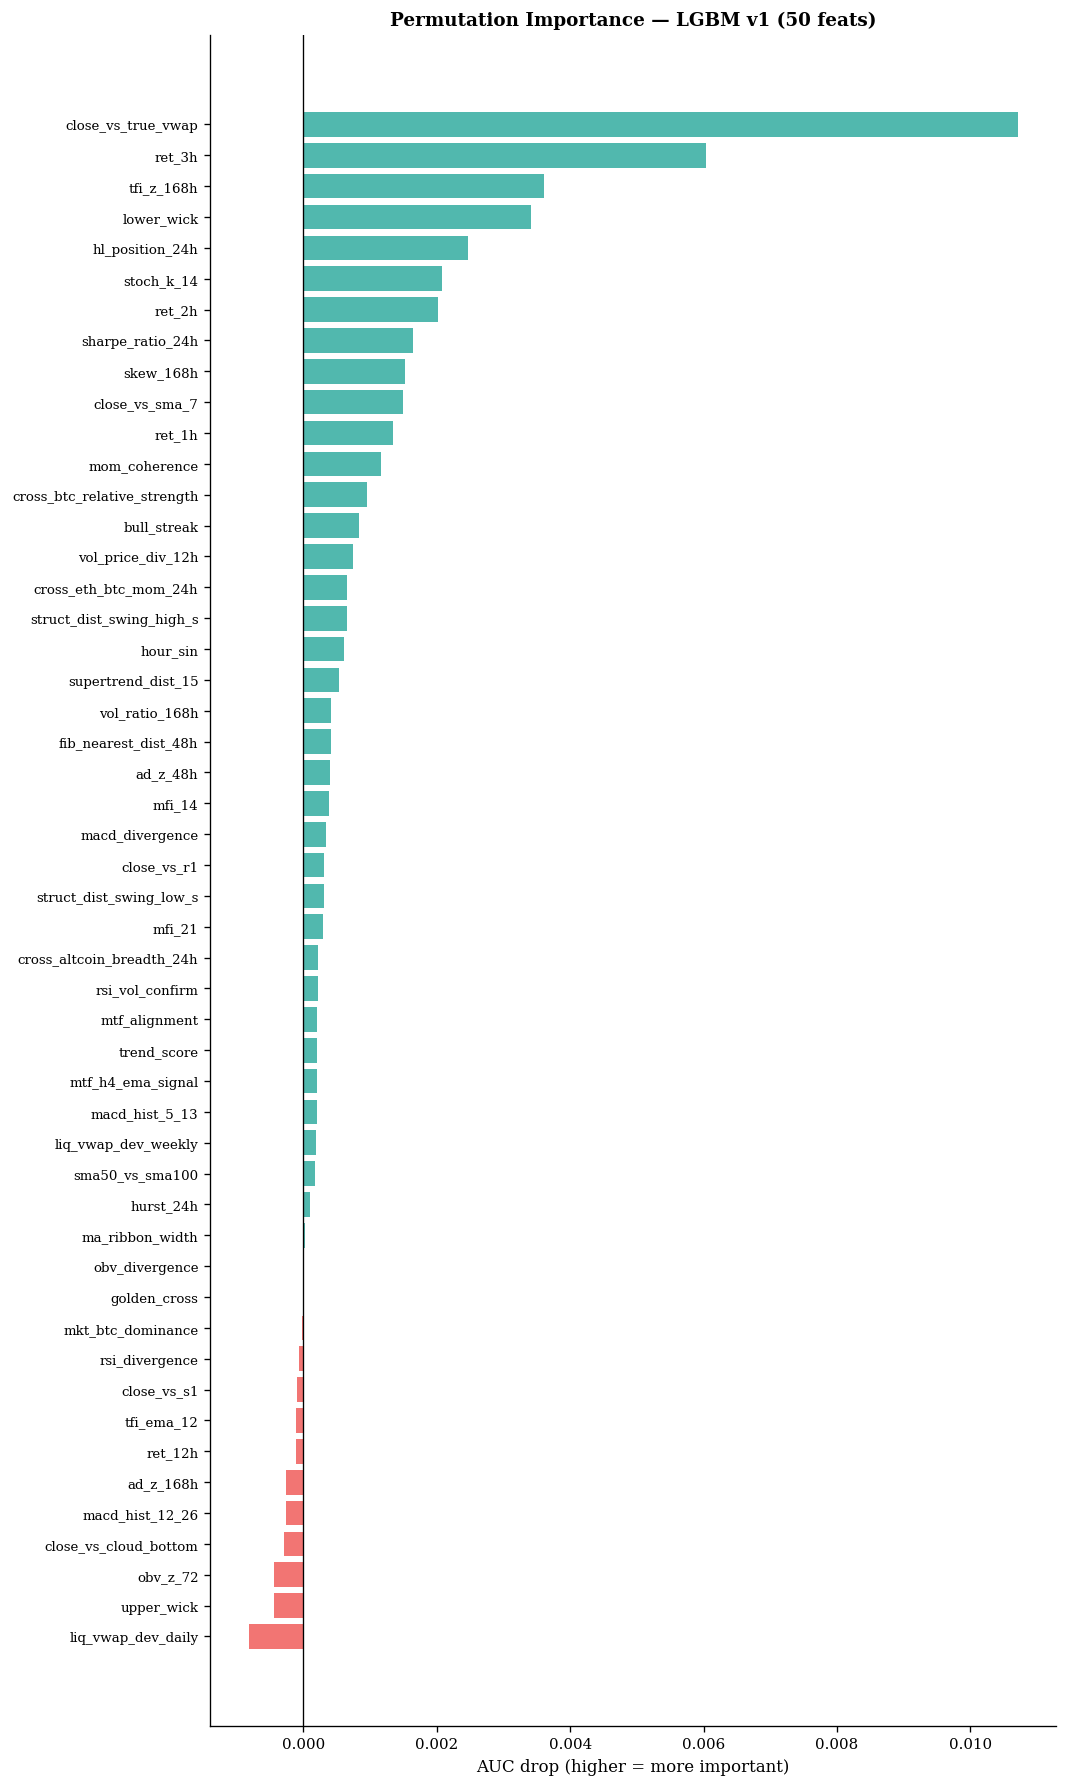

Top 10: ['close_vs_true_vwap', 'ret_3h', 'tfi_z_168h', 'lower_wick', 'hl_position_24h', 'stoch_k_14', 'ret_2h', 'sharpe_ratio_24h', 'skew_168h', 'close_vs_sma_7']


In [8]:
# ── Permutation importance of the winning feature set (last fold) ────────────
imp_mask=(df.index>=pd.Timestamp('2022-01-01'))&(df.index<OOS_START)
X_imp=df[imp_mask][SELECTED_FEATURES].fillna(0).values; y_imp=df[imp_mask][LABEL_COL].values
base_auc=roc_auc_score(y_imp, last_model.predict_proba(X_imp)[:,1]); perm_imp={}
rng=np.random.default_rng(99)
for fi,feat in enumerate(SELECTED_FEATURES):
    drops=[]
    for _ in range(3):
        Xp=X_imp.copy(); rng.shuffle(Xp[:,fi])
        drops.append(base_auc-roc_auc_score(y_imp, last_model.predict_proba(Xp)[:,1]))
    perm_imp[feat]=float(np.mean(drops))
sf=sorted(perm_imp,key=perm_imp.get,reverse=True)
fig,ax=plt.subplots(figsize=(9,max(5,len(sf)*0.30)))
ax.barh(range(len(sf)),[perm_imp[f] for f in sf],color=[GREEN if perm_imp[f]>0 else RED for f in sf],alpha=0.8)
ax.set_yticks(range(len(sf))); ax.set_yticklabels(sf,fontsize=8); ax.invert_yaxis()
ax.axvline(0,color='k',lw=0.8); ax.set_xlabel('AUC drop (higher = more important)')
ax.set_title(f'Permutation Importance — LGBM v1 ({len(sf)} feats)',fontweight='bold')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_perm_importance.png'); plt.show()
print('Top 10:', sf[:10])

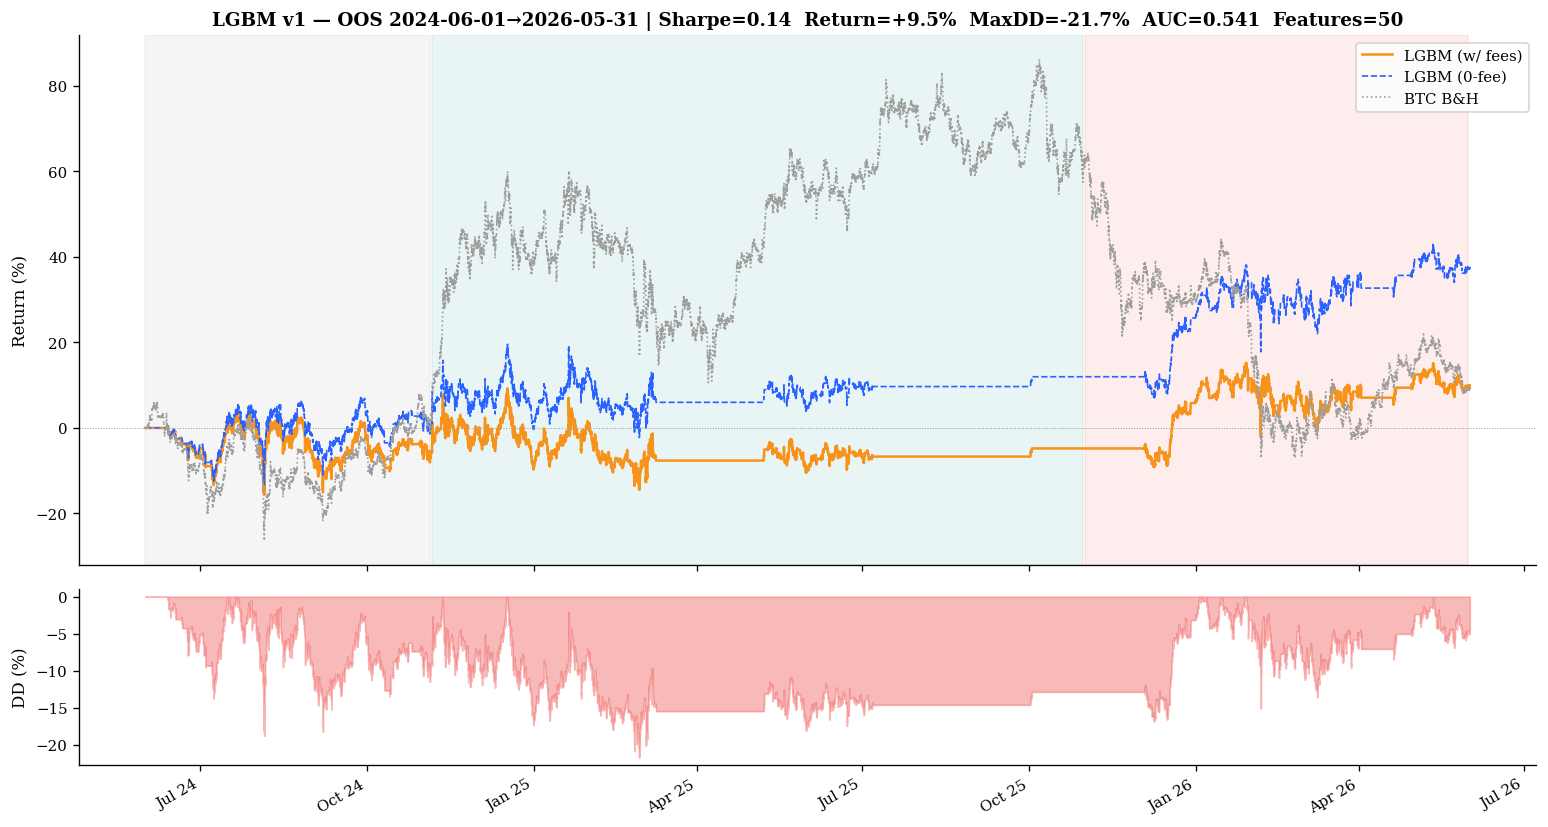

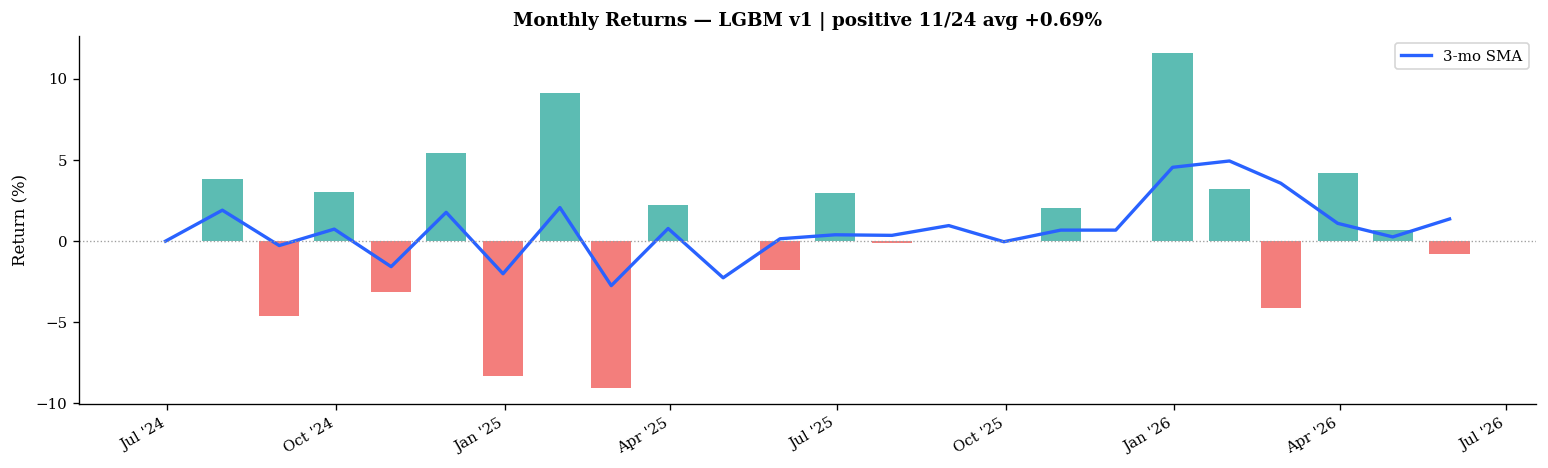

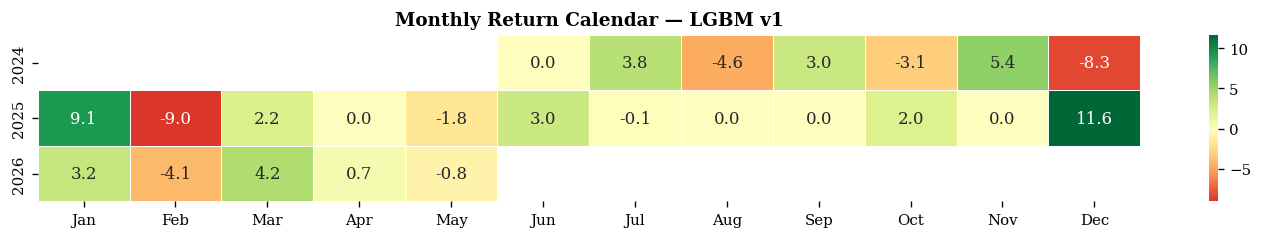

In [9]:
# ── Equity + drawdown, monthly returns, calendar heatmap ─────────────────────
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(13,7),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='LGBM (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=1.0,ls='--',label='LGBM (0-fee)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
for rname,(rs,re),rc in [('Chop',REGIME_CHOP,'#9E9E9E'),('Bull',REGIME_BULL,'#26A69A'),('Bear',REGIME_BEAR,'#EF5350')]:
    ax1.axvspan(rs,min(re,o_idx[-1]),alpha=0.10,color=rc)
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend()
ax1.set_title(f'LGBM v1 — OOS {OOS_START.date()}→{o_idx[-1].date()} | '
    f'Sharpe={_sharpe(eq_fees):.2f}  Return={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}  '
    f'AUC={auc_oos:.3f}  Features={len(SELECTED_FEATURES)}',fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'02_equity_drawdown.png'); plt.show()

eqs=pd.Series(eq_fees,index=o_idx); mret=eqs.resample('ME').last().pct_change().fillna(0)*100
fig,ax=plt.subplots(figsize=(13,4))
ax.bar(mret.index,mret.values,color=[GREEN if r>=0 else RED for r in mret],width=22,alpha=0.75)
ax.plot(mret.index,mret.rolling(3,min_periods=1).mean(),color=BLUE,lw=2,label='3-mo SMA')
ax.axhline(0,color=GREY,lw=0.8,ls=':'); ax.set_ylabel('Return (%)'); ax.legend()
ax.set_title(f'Monthly Returns — LGBM v1 | positive {int((mret>0).sum())}/{len(mret)} avg {mret.mean():+.2f}%',fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'03_monthly_returns.png'); plt.show()

cal=mret.to_frame('r'); cal['y']=cal.index.year; cal['m']=cal.index.month
piv=cal.pivot(index='y',columns='m',values='r'); piv.columns=[calendar.month_abbr[mm] for mm in piv.columns]
fig,ax=plt.subplots(figsize=(12,max(2,len(piv)*0.7)))
sns.heatmap(piv,ax=ax,cmap='RdYlGn',center=0,annot=True,fmt='.1f',linewidths=0.5)
ax.set_title('Monthly Return Calendar — LGBM v1',fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('')
fig.tight_layout(); fig.savefig(ARTS_DIR/'04_monthly_heatmap.png'); plt.show()

In [10]:
# ── Save artifacts for the meta-learner ──────────────────────────────────────
np.save(ARTS_DIR/'oos_probs.npy', oos_probs.values.astype(np.float32))
np.save(ARTS_DIR/'oos_index.npy', oos_df.index.astype('datetime64[ns]').astype(np.int64).values)
np.save(ARTS_DIR/'wfo_probs.npy', all_probs.values.astype(np.float32))
np.save(ARTS_DIR/'wfo_index.npy', all_probs.index.astype('datetime64[ns]').astype(np.int64).values)
last_model.booster_.save_model(str(ARTS_DIR/'model.txt'))
leaderboard.to_csv(ARTS_DIR/'model_grid_leaderboard.csv', index=False)

def _m(eq,t):
    return {'n_trades':len(t),'n_long':int((t['direction']=='long').sum()) if len(t) else 0,
            'n_short':int((t['direction']=='short').sum()) if len(t) else 0,
            'win_rate':round(float((t['net']>0).mean()),4) if len(t) else 0.,
            'total_ret':round(float(eq[-1]-1),4),'sharpe':round(_sharpe(eq),4),'maxdd':round(_maxdd(eq),4)}
results={'notebook':'01_lgbm_v1','created':pd.Timestamp.now().isoformat(),
    'model':'LightGBM M2Y WFO — joint MODEL_GRID + relevance-redundancy feature selection',
    'feature_selection':{'method':'relevance-redundancy filter (univariate AUC -> Spearman prune -> top-N), jointly tuned',
        'pool':len(POOL),'survivors':len(SURV),'n_selected':len(SELECTED_FEATURES),
        'top_n_features':BEST_MODEL['top_n_features'],'corr_threshold':BEST_MODEL['corr_threshold']},
    'wfo':{'scheme':'M2Y sliding','train_window_h':TRAIN_WINDOW_H,'step_size':STEP_SIZE,'embargo':EMBARGO},
    'selection':f'Validation Sharpe ({GRID_VAL_START.date()}→{(OOS_START-pd.Timedelta(hours=1)).date()}, min_trades>={MIN_TRADES_VAL}); OOS frozen/held-out',
    'val_period':f'{GRID_VAL_START.date()}→{(OOS_START-pd.Timedelta(hours=1)).date()}','val_auc':round(float(auc_val),4),
    'val_sharpe':round(float(best_overall['val_bt']['sharpe']),4),
    'oos_period':f'{OOS_START.date()}→{oos_df.index[-1].date()}','oos_auc':round(float(auc_oos),4),
    'best_model':BEST_MODEL,'selected_features':SELECTED_FEATURES,'best_params':BEST,
    'backtest_wfees':_m(eq_fees,TF),'backtest_0fee':_m(eq_0fee,T0),
    'monthly':{'mean_pct':round(float(mret.mean()),3),'positive_months':int((mret>0).sum()),'total_months':int(len(mret))},
    'permutation_importance':perm_imp,
    'artifacts':{'oos_probs':'oos_probs.npy','oos_index':'oos_index.npy (int64 ns)',
        'wfo_probs':'wfo_probs.npy','wfo_index':'wfo_index.npy (int64 ns)','model':'model.txt'}}
json.dump(results, open(ARTS_DIR/'results.json','w'), indent=2, default=float)
json.dump({'selected_features':SELECTED_FEATURES,'best_model':BEST_MODEL},
          open(ARTS_DIR/'selected_features.json','w'), indent=2, default=float)
print(f'Artifacts saved → {ARTS_DIR}')
print(json.dumps({k:v for k,v in results.items() if k not in ('selected_features','permutation_importance')},indent=2,default=float))

Artifacts saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm
{
  "notebook": "01_lgbm_v1",
  "created": "2026-06-21T18:36:54.683620",
  "model": "LightGBM M2Y WFO \u2014 joint MODEL_GRID + relevance-redundancy feature selection",
  "feature_selection": {
    "method": "relevance-redundancy filter (univariate AUC -> Spearman prune -> top-N), jointly tuned",
    "pool": 279,
    "survivors": 199,
    "n_selected": 50,
    "top_n_features": 50,
    "corr_threshold": 0.85
  },
  "wfo": {
    "scheme": "M2Y sliding",
    "train_window_h": 17520,
    "step_size": 720,
    "embargo": 12
  },
  "selection": "Validation Sharpe (2022-01-01\u21922024-05-31, min_trades>=120); OOS frozen/held-out",
  "val_period": "2022-01-01\u21922024-05-31",
  "val_auc": 0.5531,
  "val_sharpe": 1.6225,
  "oos_period": "2024-06-01\u21922026-05-31",
  "oos_auc": 0.5411,
  "best_model": {
    "top_n_features": 50,
    "corr_threshold": 0.85,
    "num_leaves": 31

=== Regime Performance Breakdown ===
                  Bars  Return  Sharpe Sortino   MaxDD  BH_Ret   Alpha
Period                                                                
Full OOS         17520   +9.5%   0.139   0.115  -21.7%   +8.9%   +0.6%
Regime 1 — Chop   3769   -6.8%  -0.419  -0.391  -18.8%   +0.6%   -7.4%
Regime 2 — Bull   8617   -1.6%  -0.054  -0.040  -21.7%  +53.8%  -55.4%
Regime 3 — Bear   5065  +15.4%   0.825   0.750  -15.1%  -32.5%  +47.9%


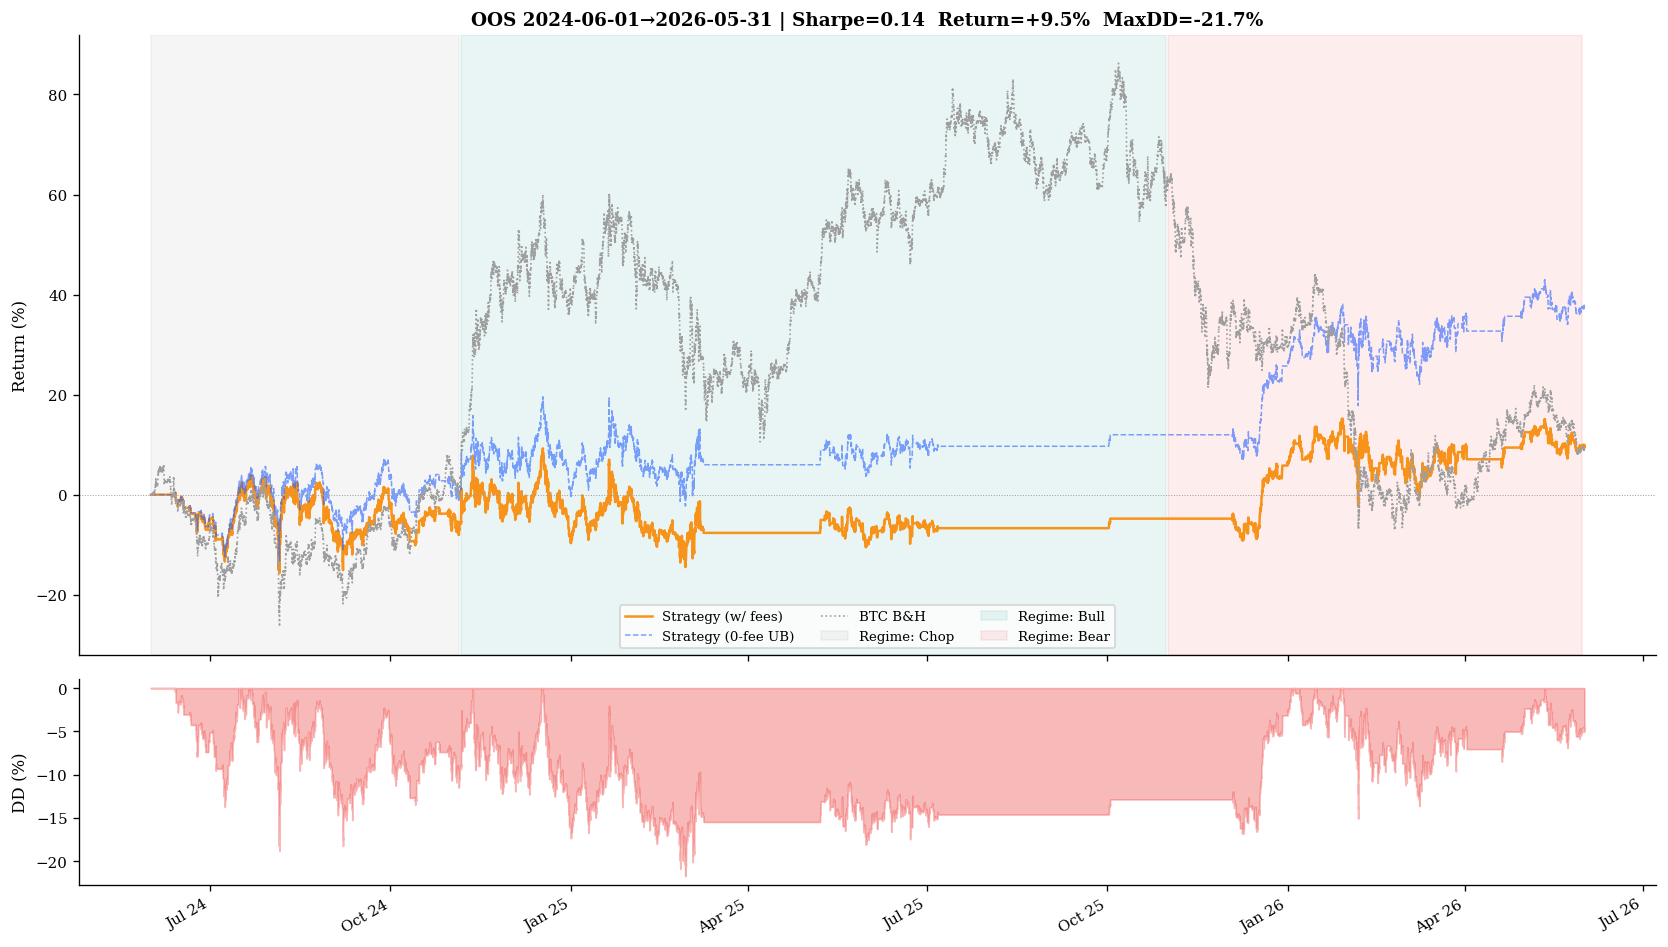

In [11]:
# ── Regime breakdown + regime-shaded equity ──────────────────────────────────
print('=== Regime Performance Breakdown ===')
print(_regime_table(eq_fees, o_idx, oos_df['close'].values).to_string())
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,8),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='Strategy (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=0.9,ls='--',alpha=0.6,label='Strategy (0-fee UB)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
for rname,(rs,re),rc in [('Chop',REGIME_CHOP,'#9E9E9E'),('Bull',REGIME_BULL,'#26A69A'),('Bear',REGIME_BEAR,'#EF5350')]:
    ax1.axvspan(rs,min(re,o_idx[-1]),alpha=0.10,color=rc,label=f'Regime: {rname}')
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend(fontsize=8,ncol=3)
ax1.set_title(f'OOS {OOS_START.date()}→{o_idx[-1].date()} | Sharpe={_sharpe(eq_fees):.2f}  '
    f'Return={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}',fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_regime.png'); plt.show()